In [ ]:
from google.colab import files
uploaded = files.upload()  # select used_phone_price_prediction_1M.csv

Saving used_phone_price_prediction_1M.csv to used_phone_price_prediction_1M (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
uploaded_filename = list(uploaded.keys())[0]
df = pd.read_csv(uploaded_filename, nrows=200000)
print(df.shape)
df.head()

(200000, 28)


,brand,model,release_year,ram_gb,storage_gb,screen_size_inches,battery_capacity,processor_score,camera_score,os_type,...,body_damage,repair_history,water_damage,city_tier,seller_type,warranty_remaining_months,box_available,charger_available,market_demand_score,resale_price
0,Realme,Realme GT,2025,4,256,6.93,4130,47,100,Android,...,0,0,0,Tier1,Individual,11,1,1,99,47891.46
1,Samsung,Galaxy S21,2024,16,64,6.29,5558,81,67,Android,...,0,0,0,Tier3,Store,8,1,0,64,17663.21
2,Apple,iPhone 11,2022,4,128,5.52,5945,59,67,iOS,...,0,0,0,Tier1,Individual,0,0,1,68,67268.20
3,Google,Pixel 6,2024,16,512,5.99,5767,84,57,Android,...,0,0,1,Tier1,Store,11,1,1,50,12626.26
4,Google,Pixel 7,2021,4,128,6.59,5336,98,44,Android,...,0,0,0,Tier3,Store,24,1,1,66,20662.25


In [ ]:
df['price_bucket'], bin_edges = pd.qcut(
    df['resale_price'], q=2, labels=["Low", "High"], retbins=True
)
df['price_bucket'].value_counts()

band_ranges = {
    "Low": (round(bin_edges[0]), round(bin_edges[1])),
    "High": (round(bin_edges[1]), round(bin_edges[2])),
}
print(band_ranges)

{'Low': (2000, 18549), 'High': (18549, 150358)}


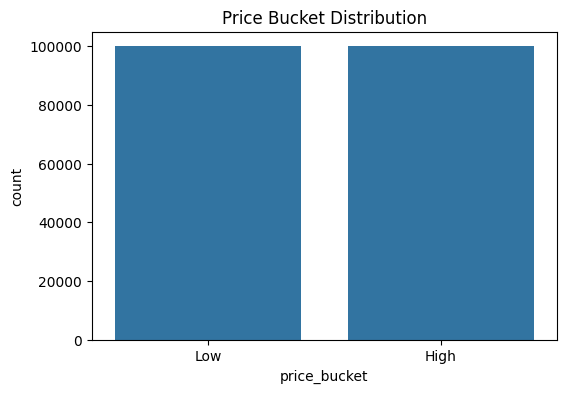

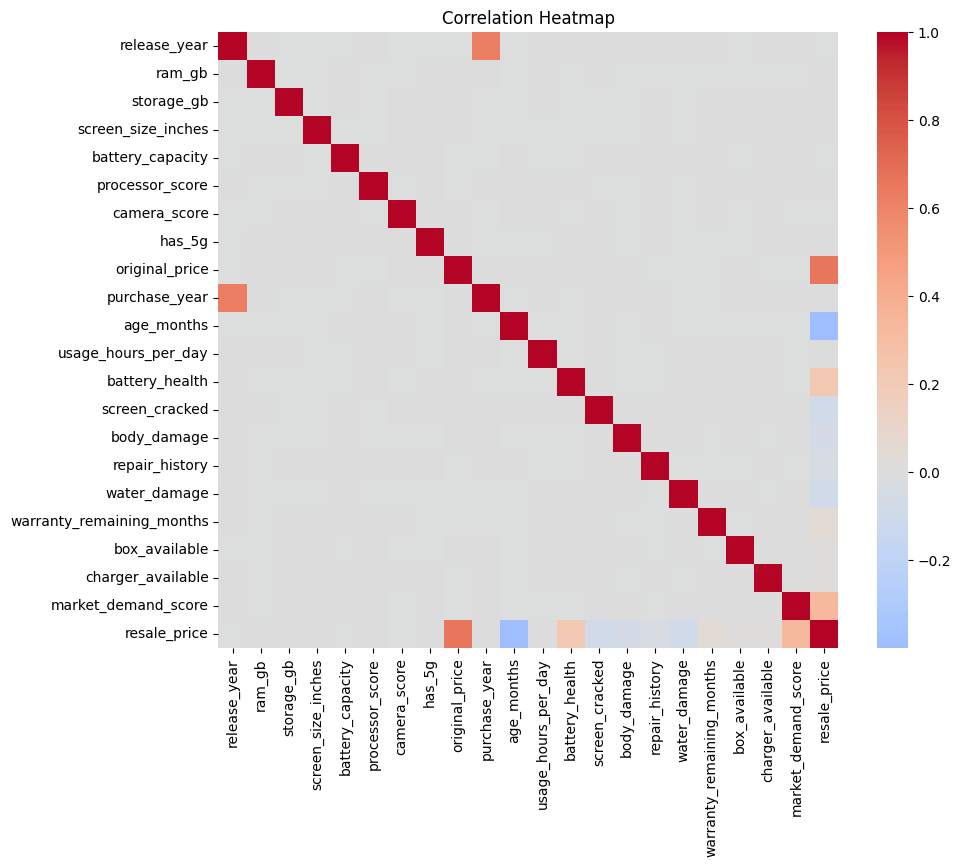

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='price_bucket', order=["Low","High"])
plt.title("Price Bucket Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop(columns=['resale_price', 'price_bucket'])
y = df['price_bucket']

cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()

Categorical columns: ['brand', 'model', 'os_type', 'condition', 'city_tier', 'seller_type']


,brand,model,release_year,ram_gb,storage_gb,screen_size_inches,battery_capacity,processor_score,camera_score,os_type,...,screen_cracked,body_damage,repair_history,water_damage,city_tier,seller_type,warranty_remaining_months,box_available,charger_available,market_demand_score
0,3,13,2025,4,256,6.93,4130,47,100,0,...,0,0,0,0,0,0,11,1,1,99
1,4,1,2024,16,64,6.29,5558,81,67,0,...,0,0,0,0,2,1,8,1,0,64
2,0,18,2022,4,128,5.52,5945,59,67,1,...,0,0,0,0,0,0,0,0,1,68
3,1,9,2024,16,512,5.99,5767,84,57,0,...,0,0,0,1,0,1,11,1,1,50
4,1,10,2021,4,128,6.59,5336,98,44,0,...,0,0,0,0,2,1,24,1,1,66


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(160000, 27) (40000, 27)


In [ ]:
rf_bucket = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_bucket.fit(X_train, y_train)

y_pred = rf_bucket.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.935

Classification Report:
               precision    recall  f1-score   support

        High       0.93      0.94      0.94     20000
         Low       0.94      0.93      0.93     20000

    accuracy                           0.94     40000
   macro avg       0.94      0.94      0.93     40000
weighted avg       0.94      0.94      0.93     40000



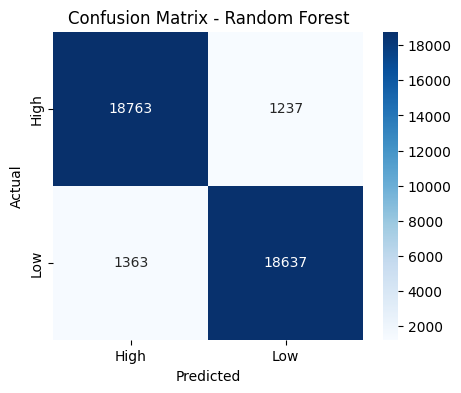

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=rf_bucket.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_bucket.classes_, yticklabels=rf_bucket.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

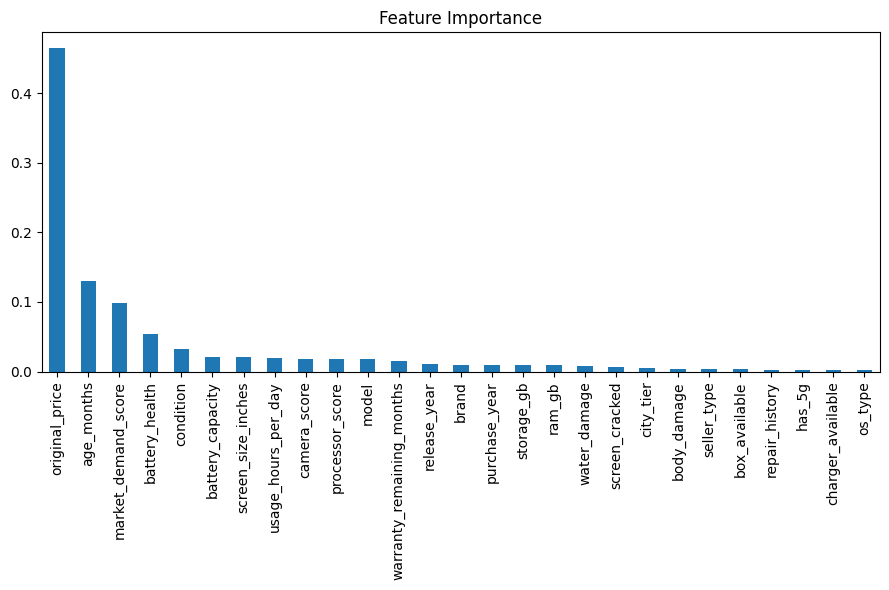

In [ ]:
importances = pd.Series(rf_bucket.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9,6))
importances.plot(kind='bar')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": rf_bucket
}

results = []
for name, model in models.items():
    if name == "Random Forest":
        preds = model.predict(X_test)
    elif name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results.append({"Model": name, "Accuracy": round(acc, 4)})
    print(f"{name}: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

Logistic Regression: 0.9127
Decision Tree: 0.8874
KNN: 0.8237
Random Forest: 0.9350


,Model,Accuracy
0,Random Forest,0.9350
1,Logistic Regression,0.9127
2,Decision Tree,0.8874
3,KNN,0.8237


/tmp/ipykernel_2066/102705255.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")


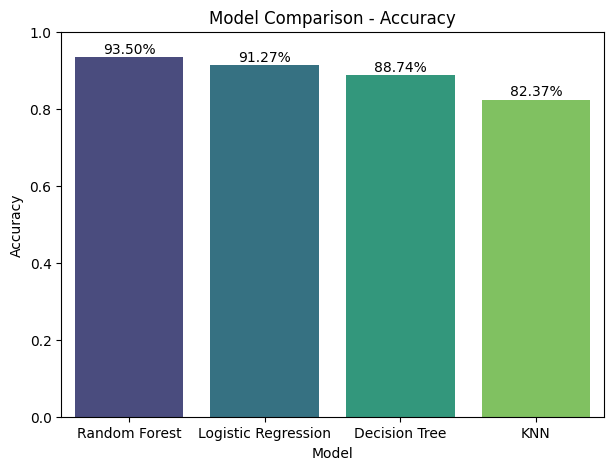

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")
plt.title("Model Comparison - Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')
plt.show()

In [ ]:
def predict_resale_price_bucket(input_dict):
    row = input_dict.copy()
    for col, le in encoders.items():
        row[col] = le.transform([row[col]])[0]

    input_df = pd.DataFrame([row])[X.columns]
    predicted_bucket = rf_bucket.predict(input_df)[0]
    low, high = band_ranges[predicted_bucket]

    return f"{predicted_bucket} (₹{low:,} - ₹{high:,})"

In [ ]:
sample_input = {
    'brand': 'Samsung',
    'model': 'Galaxy S21',
    'release_year': 2024,
    'ram_gb': 8,
    'storage_gb': 128,
    'screen_size_inches': 6.5,
    'battery_capacity': 5000,
    'processor_score': 80,
    'camera_score': 70,
    'os_type': 'Android',
    'has_5g': 1,
    'original_price': 60000,
    'purchase_year': 2024,
    'age_months': 18,
    'usage_hours_per_day': 4.5,
    'condition': 'Good',
    'battery_health': 85,
    'screen_cracked': 0,
    'body_damage': 0,
    'repair_history': 0,
    'water_damage': 0,
    'city_tier': 'Tier1',
    'seller_type': 'Individual',
    'warranty_remaining_months': 6,
    'box_available': 1,
    'charger_available': 1,
    'market_demand_score': 70
}

result = predict_resale_price_bucket(sample_input)
print("Predicted Resale Price Range:", result)

Predicted Resale Price Range: High (₹18,549 - ₹150,358)


In [ ]:
import joblib

bundle = {
    'model': rf_bucket,
    'encoders': encoders,
    'band_ranges': band_ranges,
    'feature_columns': list(X.columns)
}

joblib.dump(bundle, 'resale_price_bundle.pkl')

import os
print(os.path.exists('resale_price_bundle.pkl'))

True


In [ ]:
from google.colab import files
files.download('resale_price_bundle.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>